In [1]:
import contextily as cx
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely import Point
import json
import yaml

ox.settings.use_cache = True
ox.settings.log_console = False

with open("../plotting_config.yaml", "r") as fp:
    plotting_config = yaml.safe_load(fp)

matplotlib.rcParams["svg.hashsalt"] = "42"

colors = ["#41afaa", "#466eb4", "#00a0e1", "#e6a532", "#d7642c", "#af4b91"]

In [2]:
CITY = "budapest"
DIR = f"../data/stops/{CITY}/20250428/"

In [3]:
with open(f"{DIR}/accessible_stops.json", "r") as fp:
    accessible_stops = json.load(fp)

In [ ]:
stops = pd.read_csv(f"{DIR}/stops_with_centrality.csv", engine="pyarrow")
stops["geometry"] = stops.apply(lambda x: Point(x["stop_lon"], x["stop_lat"]), axis=1)
stops = gpd.GeoDataFrame(stops, geometry="geometry", crs=4326)
stops.to_crs(23700, inplace=True)
stops.head(3)

,stop_id,stop_name,stop_lat,stop_lon,clust,Node,Eigenvector Centrality,Degree Centrality,Closeness Centrality,Betweenness Centrality,geometry
0,007877,Bíróság,47.519544,18.978060,2120,2120.0,3.231466e-07,0.000984,0.054053,0.006866,POINT (644774.508 241738.061)
1,007878,Bíróság,47.519418,18.978021,2120,2120.0,3.231466e-07,0.000984,0.054053,0.006866,POINT (644771.558 241724.055)
2,007879,"Római úti lakótelep, Varsa utca",47.570863,19.058543,1752,1752.0,6.260713e-09,0.000492,0.049765,0.000000,POINT (650835.138 247441.201)


In [5]:
# result = gpd.read_file("../output/hour40.geojson")

# walk_5m = gpd.read_file("../output/isochrones_5minute_walk.geojson", engine="pyogrio")

In [5]:
isochrones = gpd.read_file(f"../output/{CITY}/isochrones.geojson")

In [6]:
walk_5m = isochrones[(isochrones["costing"] == "walk") & (isochrones["range"] == 5)]

In [7]:
m4 = gpd.read_file(f"../data/osm/{CITY}/routes/m4.geojson")
t4 = gpd.read_file(f"../data/osm/{CITY}/routes/tram4.geojson")
t47 = gpd.read_file(f"../data/osm/{CITY}/routes/tram47.geojson")

In [8]:
t4["name"].unique()

array(['4 => Széll Kálmán tér M', '4 => Újbuda-központ M', None],
      dtype=object)

(647292.0782325359, 653242.9923605052, 234917.79794735883, 241493.04576998056)

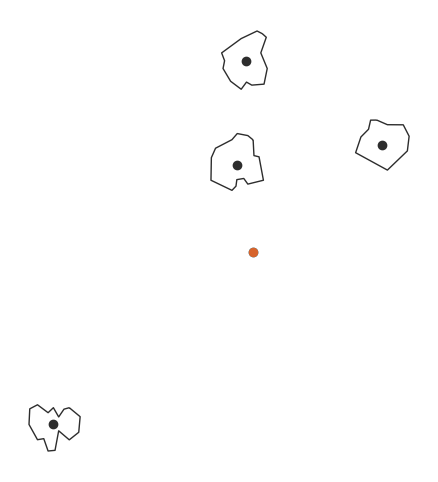

In [9]:
stop = "007974"
h = 0
stop = "CSLM4FT1"  # Fővám square
h = 40
selected = set(
    [
        # "F01006",  # Kálvin
        "CSF00960",  # Deák
        # "CSF01019",  # Astoria
        # "F02201",  # Móricz
        "CSLMXKPB",  # Keleti
        "CSLM3NYA",  # Nyugati
        "CSLM4KFD",  # Kelenföld
    ]
)
# nodes = set(d10m[f"{stop}_network_{h}"].nodes)
nodes = set(accessible_stops[stop])
fig, ax = plt.subplots(figsize=(6, 6))
# result.query(f"stop_id == '{stop}' & hour == {h}").to_crs(23700).plot(
#     ax=ax, ec=colors[2], fc=colors[2] + "7f"
#)
stops.query(f"stop_id == '{stop}'").to_crs(23700).plot(
    ax=ax, ec=colors[2], fc=colors[2] + "7f"
)
walk_5m[walk_5m["stop_id"].isin(selected)].to_crs(23700).plot(
    ax=ax, fc="none", ec="#2d2d2d"
)
stops[stops["stop_id"].isin(nodes & selected)].to_crs(23700).plot(ax=ax, color="#2d2d2d")
stops[stops["stop_id"] == stop].to_crs(23700).plot(ax=ax, color=colors[4])
ax.margins(0.05)
ax.axis("off")

M4, 4/6, 47/49

In [10]:
railway = ox.features_from_point(
    (47.4868, 19.057), tags={"route": ["subway"], "ref": ["M4"]}, dist=5000
)

In [11]:
tram474 = ox.features_from_point(
    (47.4868, 19.057), tags={"route": ["tram"], "ref": ["47"]}, dist=10000
)

In [12]:
stops_osm = ox.features_from_point(
    (47.4868, 19.057),
    tags={
        "public_transport": ["stop"],
    },
    dist=5000,
)

In [13]:
gtfs_stops = pd.read_csv(f"../data/gtfs/{CITY}/urbansys/stops.txt", engine="pyarrow")
gtfs_trips = pd.read_csv(f"../data/gtfs/{CITY}/urbansys/trips.txt", engine="pyarrow")
gtfs_routes = pd.read_csv(f"../data/gtfs/{CITY}/urbansys/routes.txt", engine="pyarrow")

In [14]:
route_tram47 = int(
    gtfs_routes.query("route_short_name == '47'")["route_id"].tolist()[0]
)
trips_tram47 = gtfs_trips.query("route_id==@route_tram47")

In [15]:
gtfs_stops_times = pd.read_csv(f"../data/gtfs/{CITY}/urbansys/stop_times.txt", engine="pyarrow")

In [16]:
gtfs_stops[["stop_id", "stop_name"]]

,stop_id,stop_name
0,002133,"Örs vezér tere M+H, déli tárolótér"
1,002138,Kőbánya alsó vasútállomás
2,003002,Puskás Ferenc Stadion M
3,003103,"Káposztásmegyer, Mogyoródi-patak"
4,003105,Bécsi út / Vörösvári út
...,...,...
5914,LMXKPJ,Keleti pályaudvar [J]
5915,LMXKPK,Keleti pályaudvar [K]
5916,LMXKPL,Keleti pályaudvar [L]
5917,LMXKPM,Keleti pályaudvar [M]


In [17]:
# gtfs_stops_times[gtfs_stops_times["trip_id"].isin(trips_tram47["trip_id"]) & (gtfs_stops_times["arrival_time"]>"16:00") & (gtfs_stops_times["arrival_time"]<"17:00")]
gtfs_stops_times[
    gtfs_stops_times["trip_id"].isin(trips_tram47["trip_id"])
    & (gtfs_stops_times["trip_id"] == "C10881692")
].merge(gtfs_stops[["stop_id", "stop_name"]], on="stop_id", how="left")

,trip_id,stop_id,arrival_time,departure_time,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,stop_name


In [18]:
# Deák Ferenc tér M, Astoria M, Kálvin tér M, Fővám tér M
deak_fovam_stops = ["F00922", "F01006", "F01013", "007884"]
deak_fovam = stops[stops["stop_id"].isin(deak_fovam_stops)].to_crs(23700).union_all().envelope.buffer(
    50
)

<Axes: >

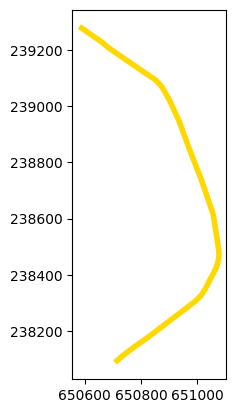

In [19]:
gpd.clip(t47.to_crs(23700), deak_fovam).query("to=='Városház tér'").plot(
    color="#FFD800", lw=4
)

In [20]:
route_tram4 = int(gtfs_routes.query("route_short_name == '4'")["route_id"].tolist()[0])
trips_tram4 = gtfs_trips.query("route_id==@route_tram4")

In [21]:
gtfs_stops_times[
    gtfs_stops_times["trip_id"].isin(trips_tram4["trip_id"])
    & (gtfs_stops_times["arrival_time"] > "16:00")
    & (gtfs_stops_times["arrival_time"] < "17:00")
].sort_values("arrival_time")

,trip_id,stop_id,arrival_time,departure_time,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled


In [22]:
gtfs_stops_times[
    gtfs_stops_times["trip_id"].isin(trips_tram4["trip_id"])
    & (gtfs_stops_times["trip_id"] == "C1134667641")
].merge(gtfs_stops[["stop_id", "stop_name"]], on="stop_id", how="left")

,trip_id,stop_id,arrival_time,departure_time,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,stop_name


In [23]:
nyugati_rakoczi_stops = ["F00935", "F01081", "F01037", "F01112", "F01169", "F01201"]
# Nyugati pályaudvar M, Oktogon M, Király utca / Erzsébet körút, Wesselényi utca / Erzsébet körút, Blaha Lujza tér M, Rákóczi tér M
nyugati_rakoczi = stops[
    stops["stop_id"].isin(nyugati_rakoczi_stops)
].to_crs(23700).union_all().envelope.buffer(50)

<Axes: >

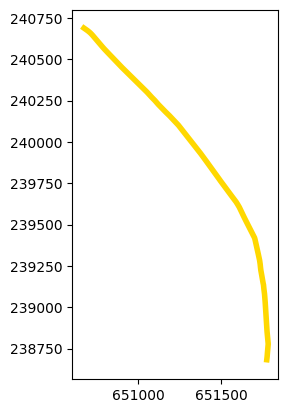

In [24]:
gpd.clip(t4.to_crs(23700), nyugati_rakoczi).query("to=='Újbuda-központ M'").plot(
    color="#FFD800", lw=4
)

In [25]:
unioned_bkk_ac = gpd.GeoDataFrame(geometry=[walk_5m[walk_5m["stop_id"].isin(nodes)].union_all()], crs=4326)

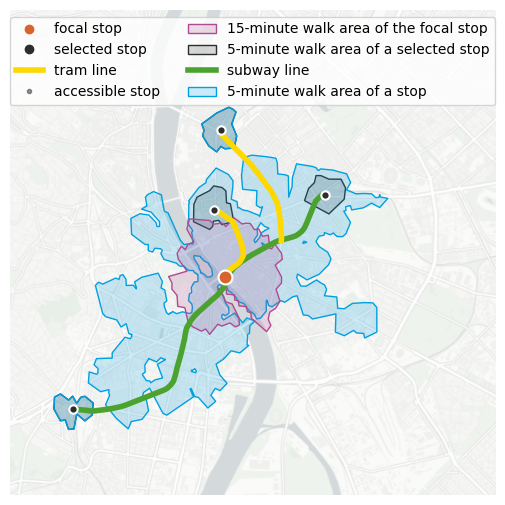

In [29]:
stop = "CSLM4FT1"  # Fővám square
h = 40
selected = set(
    [
        # "F01006",  # Kálvin
        "CSF00960",  # Deák
        # "CSF01019",  # Astoria
        # "F02201",  # Móricz
        "CSLMXKPB",  # Keleti
        "CSLM3NYA",  # Nyugati
        "CSLM4KFD",  # Kelenföld
    ]
)
# nodes = set(d10m[f"{stop}_network_{h}"].nodes)
nodes = set(accessible_stops[stop])
fig, ax = plt.subplots(figsize=(6.3, 6.3))
# result.query(f"stop_id == '{stop}' & hour == {h}").to_crs(23700).plot(
#     ax=ax, ec=colors[2], fc=colors[2] + "30"
# )
# stops.query(f"stop_id == '{stop}'").to_crs(23700).plot(
#     ax=ax, ec=colors[2], fc=colors[2] + "7f"
# )
walk_5m[walk_5m["stop_id"].isin(selected)].to_crs(23700).plot(
    ax=ax, fc="#2d2d2d2d", ec="#2d2d2d"
)
unioned_bkk_ac.to_crs(23700).plot(
    ax=ax, ec=colors[2], fc=colors[2] + "30"
)
m4.query("to=='Keleti pályaudvar'").to_crs(23700).plot(
    color="#4CA22F",
    lw=4,
    ax=ax,
    zorder=30,
)
gpd.clip(t4.to_crs(23700), nyugati_rakoczi).query("to=='Újbuda-központ M'").plot(
    color="#FFD800",
    lw=4,
    ax=ax,
    zorder=30,
)
gpd.clip(t47.to_crs(23700), deak_fovam).query("to=='Városház tér'").plot(
    color="#FFD800",
    lw=4,
    ax=ax,
    zorder=30,
)

# (
#     stops[stops["stop_id"].isin(nodes - selected)].plot(
#         ax=ax,
#         color="#2d2d2d80",
#         markersize=2,
#         zorder=25,
#     )
# )
stops[stops["stop_id"].isin(nodes & selected)].plot(
    ax=ax,
    color="#2d2d2d",
    ec="white",
    lw=1.5,
    zorder=40,
)
# stops[stops["stop_id"].isin(deak_fovam_stops[1:-1]+nyugati_rakoczi_stops[1:-1])].plot(
#     ax=ax,
#     color="#FFD800",
#     ec="white",
#     zorder=40,
# )
stops[stops["stop_id"] == stop].plot(
    ax=ax,
    color=colors[4],
    ec="white",
    lw=1.5,
    zorder=50,
    markersize=100,
)
ax.set_xlim([646750, 655750])
ax.set_ylim([234000, 243000])
cx.add_basemap(
    ax,
    crs=23700,
    source=cx.providers.CartoDB.PositronNoLabels,
    alpha=1,
    attribution=False,
)
legend_elements = []

legend_elements.append(
    Line2D(
        [0],
        [0],
        color=colors[4],
        lw=4,
        linestyle="none",
        marker="o",
        label="focal stop",
    )
)
legend_elements.append(
    Line2D(
        [0],
        [0],
        color="#2d2d2d",
        lw=4,
        linestyle="none",
        marker="o",
        label="selected stop",
    )
)
legend_elements.append(
    Line2D(
        [0],
        [0],
        color="#FFD800",
        lw=4,
        label="tram line",
    )
)
legend_elements.append(
    Line2D(
        [0],
        [0],
        color="#2d2d2d80",
        lw=1,
        linestyle="none",
        marker=".",
        label="accessible stop",
    )
)
legend_elements.append(
    Patch(
        ec=colors[5], fc=colors[5] + "30", label="15-minute walk area of the focal stop"
    )
)
legend_elements.append(
    Patch(ec="#2d2d2d", fc="#2d2d2d2d", label="5-minute walk area of a selected stop")
)
legend_elements.append(
    Line2D(
        [0],
        [0],
        color="#4CA22F",
        lw=4,
        label="subway line",
    )
)
legend_elements.append(
    Patch(ec=colors[2], fc=colors[2] + "30", label="5-minute walk area of a stop")
)
isochrones.query("costing=='walk' & range==15 & stop_id=='CSLM4FT1'").to_crs(
    23700
).plot(ec=colors[5], fc=colors[5] + "30", ax=ax, zorder=5)

ax.margins(0)
ax.axis("off")

for i in plotting_config["formats"]:
    fig.savefig(
        f"../output/figures/method_no_legend.{i}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
        metadata=plotting_config["metadata"][i],
    )

legend = ax.legend(handles=legend_elements, ncols=2, loc="upper center")
legend.set_zorder(100)

for i in plotting_config["formats"]:
    fig.savefig(
        f"../output/figures/method.{i}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
        metadata=plotting_config["metadata"][i],
    )